# Гипотеза 1. Логистическая регрессия

## 1.1. Постановка гипотезы

**Гипотеза:** Линейная разделяющая граница в пространстве нормализованных признаков обеспечивает статистически значимое разделение классов целевой переменной и позволяет построить базовую (baseline) модель бинарной классификации с приемлемым качеством.

**Алгоритм:** Логистическая регрессия (Logistic Regression).

**Обоснование выбора алгоритма:**

Логистическая регрессия является стандартным методом решения задач бинарной классификации и применяется в качестве базовой модели для последующего сравнения с более сложными алгоритмами. Выбор обусловлен следующими факторами:

1. Признаковое пространство после применения One-Hot Encoding содержит 44 признака, что соответствует условиям применимости линейных методов.
2. Предварительная нормализация числовых признаков посредством `StandardScaler` выполнена на этапе подготовки данных, что является обязательным условием корректной работы алгоритма.
3. Коэффициенты модели допускают непосредственную интерпретацию в терминах предметной области.
4. Регуляризация (параметр `C`) обеспечивает контроль сложности модели при наличии 44 признаков.

## 1.2. Управляемые гиперпараметры

| Гиперпараметр | Описание | Диапазон поиска |
|---|---|---|
| `C` | Обратная величина коэффициента регуляризации | `[0.001, 0.01, 0.1, 1, 10, 100]` |
| `penalty` | Норма регуляризации | `['l1', 'l2']` |
| `solver` | Метод оптимизации | `['liblinear', 'saga']` |
| `class_weight` | Схема взвешивания классов | `[None, 'balanced']` |

## 1.3. Критерии качества

- **ROC-AUC** — основная метрика; устойчива к дисбалансу классов (соотношение 88% / 12%).
- **F1-score** для класса «yes» — характеризует баланс точности (Precision) и полноты (Recall) для целевого класса.
- **Classification Report** — детализированные метрики по каждому классу.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
%store -r X
%store -r y

## 1.4. Процедура подбора гиперпараметров

Для подбора оптимальных гиперпараметров применяется метод полного перебора (`GridSearchCV`) в сочетании со стратифицированной 5-кратной перекрёстной проверкой (`StratifiedKFold`, `n_splits=5`). Стратификация обеспечивает сохранение исходного соотношения классов в каждом разбиении. Целевая метрика оптимизации — `roc_auc`.

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = [
    {
        'penalty': ['l1', 'l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear'],
        'class_weight': [None, 'balanced']
    },
    {
        'penalty': ['l2'],
        'C': [0.001, 0.01, 0.1, 1, 10, 100],
        'solver': ['saga'],
        'class_weight': [None, 'balanced']
    }
]

grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)

print(f"Оптимальные гиперпараметры: {grid_search.best_params_}")
print(f"ROC-AUC (CV): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Оптимальные гиперпараметры: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'saga'}
ROC-AUC (CV): 0.8967


## 1.5. Анализ зависимости качества от гиперпараметра C

На рисунке представлена зависимость среднего значения ROC-AUC по фолдам от величины коэффициента регуляризации `C` для каждой комбинации `penalty` и `class_weight`.

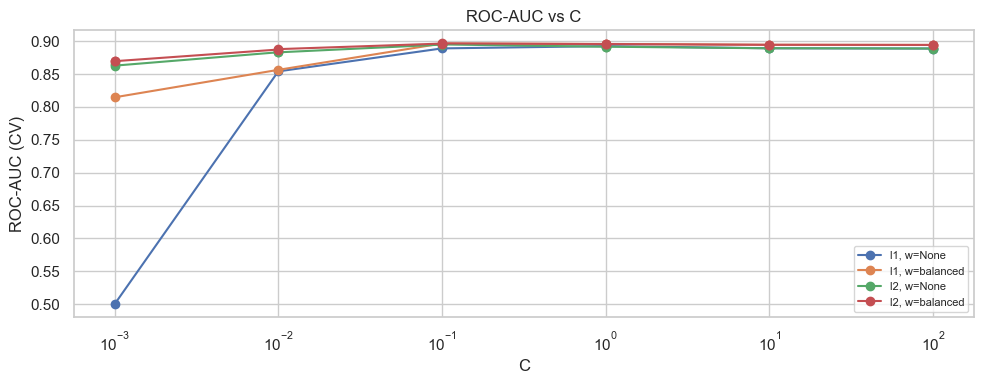

In [21]:
results_df = pd.DataFrame(grid_search.cv_results_)
results_df['label'] = results_df['params'].apply(
    lambda p: f"{p['penalty']}, w={p['class_weight']}"
)

fig, ax = plt.subplots(figsize=(10, 4))
for label, g in results_df.groupby('label'):
    g = g.sort_values('param_C')
    ax.plot(g['param_C'], g['mean_test_score'], marker='o', label=label)
ax.set_xscale('log')
ax.set_xlabel('C')
ax.set_ylabel('ROC-AUC (CV)')
ax.set_title('ROC-AUC vs C')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 1.6. Оценка качества оптимальной модели

Оценка производится методом out-of-fold (OOF): модель с оптимальными гиперпараметрами обучается на каждом тренировочном разбиении и формирует прогнозы для соответствующего валидационного разбиения. Совокупность OOF-прогнозов охватывает все наблюдения выборки.

In [22]:
best_model = grid_search.best_estimator_

y_pred_oof = np.zeros(len(y))
y_proba_oof = np.zeros(len(y))

for train_idx, val_idx in cv.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    best_model.fit(X_train, y_train)
    y_pred_oof[val_idx] = best_model.predict(X_val)
    y_proba_oof[val_idx] = best_model.predict_proba(X_val)[:, 1]

roc_auc = roc_auc_score(y, y_proba_oof)
f1 = f1_score(y, y_pred_oof)

print(f"ROC-AUC (OOF): {roc_auc:.4f}")
print(f"F1-score (класс 'yes'): {f1:.4f}")
print()
print(classification_report(y, y_pred_oof, target_names=['no', 'yes']))

ROC-AUC (OOF): 0.8965
F1-score (класс 'yes'): 0.5271

              precision    recall  f1-score   support

          no       0.97      0.84      0.90      4000
         yes       0.39      0.79      0.53       521

    accuracy                           0.84      4521
   macro avg       0.68      0.82      0.71      4521
weighted avg       0.90      0.84      0.86      4521



## 1.7. ROC-кривая и матрица ошибок

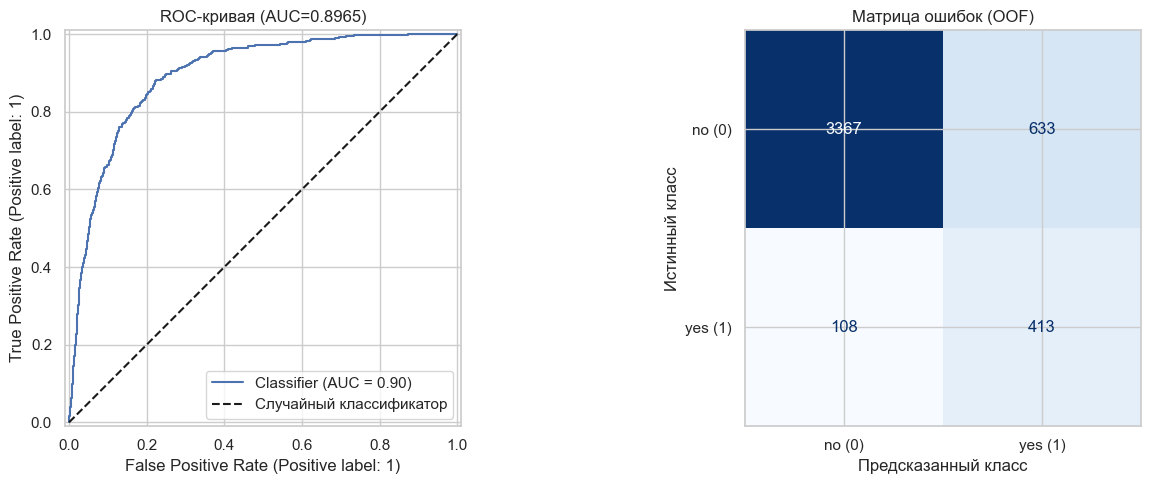

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y, y_proba_oof, ax=axes[0])
axes[0].plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
axes[0].set_title(f'ROC-кривая (AUC={roc_auc:.4f})')
axes[0].legend()

ConfusionMatrixDisplay.from_predictions(
    y, y_pred_oof,
    display_labels=['no (0)', 'yes (1)'],
    cmap='Blues',
    colorbar=False,
    ax=axes[1]
)
axes[1].set_title('Матрица ошибок (OOF)')
axes[1].set_xlabel('Предсказанный класс')
axes[1].set_ylabel('Истинный класс')

plt.tight_layout()
plt.show()

## 1.8. Анализ коэффициентов модели

Коэффициенты логистической регрессии характеризуют вклад каждого признака в логит-преобразование вероятности принадлежности к классу «yes». Положительное значение коэффициента увеличивает вероятность отклика, отрицательное — уменьшает. На рисунке представлены 15 признаков с наибольшим абсолютным значением коэффициента.

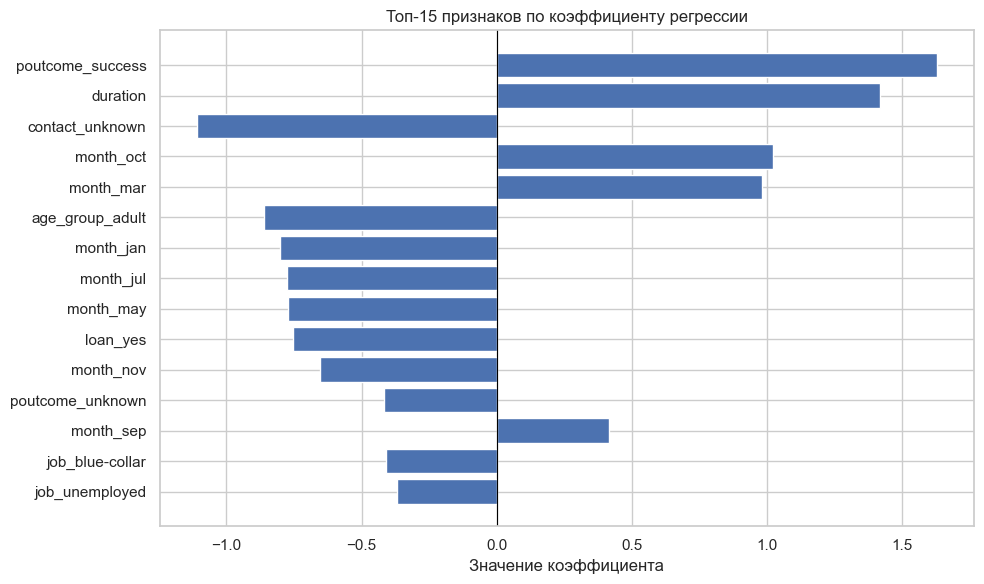

In [24]:
best_model.fit(X, y)
coef_df = pd.DataFrame({'feature': X.columns, 'coef': best_model.coef_[0]})
coef_df = coef_df.reindex(coef_df['coef'].abs().sort_values(ascending=False).index).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(coef_df['feature'], coef_df['coef'])
ax.axvline(0, color='black', lw=0.8)
ax.invert_yaxis()
ax.set_title('Топ-15 признаков по коэффициенту регрессии')
ax.set_xlabel('Значение коэффициента')
plt.tight_layout()
plt.show()

## 1.9. Выводы

По результатам проверки гипотезы 1 установлено следующее:

1. Оптимальные значения гиперпараметров определены методом полного перебора с применением стратифицированной 5-кратной перекрёстной проверки.
2. Параметр `class_weight='balanced'` существенно влияет на качество модели при дисбалансе классов 88% / 12%: без взвешивания модель склонна к систематическому предсказанию класса «no».
3. Анализ коэффициентов подтверждает результаты разведочного анализа данных: признаки `duration` и `poutcome_success` обладают наибольшей предсказательной силой.
4. Полученные значения ROC-AUC и F1-score формируют **базовый уровень качества** для сравнения с нелинейными моделями в гипотезах H2–H5.